🔍 Loading iEEG: rest_off_sub-01_c_ieeg.npz
Loading LCMV: source_estimate_LCMV.h5

📊 Processing L_M1
  → iEEG: ECOG-8-9-L @ 250.0 Hz
Requested: [-40.0, -12.5, 66.0]
Closest active source: [-40.0, -15.0, 65.0] (dist: 2.7 mm)


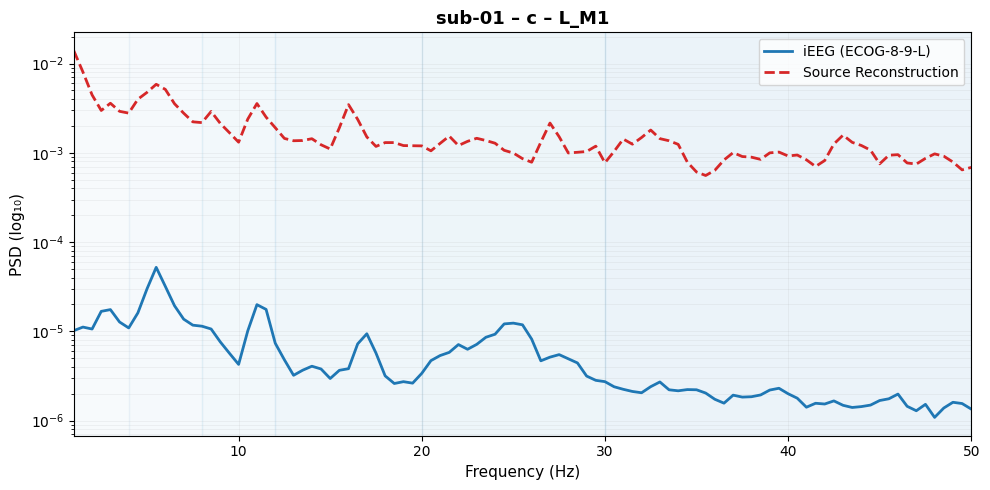


📊 Processing R_M1
  → iEEG: ECOG-8-9-R @ 250.0 Hz
Requested: [40.0, -12.5, 66.0]
Closest active source: [40.0, -15.0, 65.0] (dist: 2.7 mm)


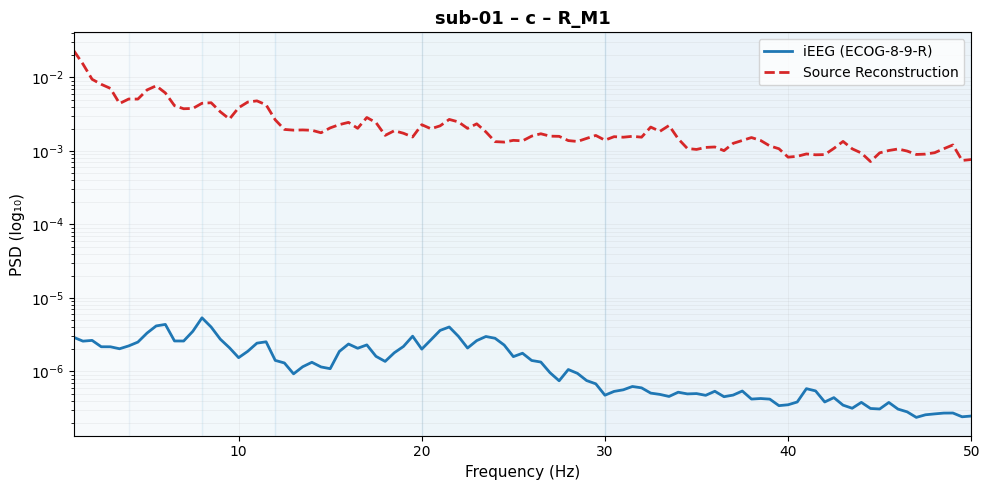


📊 Processing L_STN
  → iEEG: STN-L @ 250.0 Hz
Requested: [-11.89, -14.51, -6.4]
Closest active source: [-10.0, -15.0, -5.0] (dist: 2.4 mm)


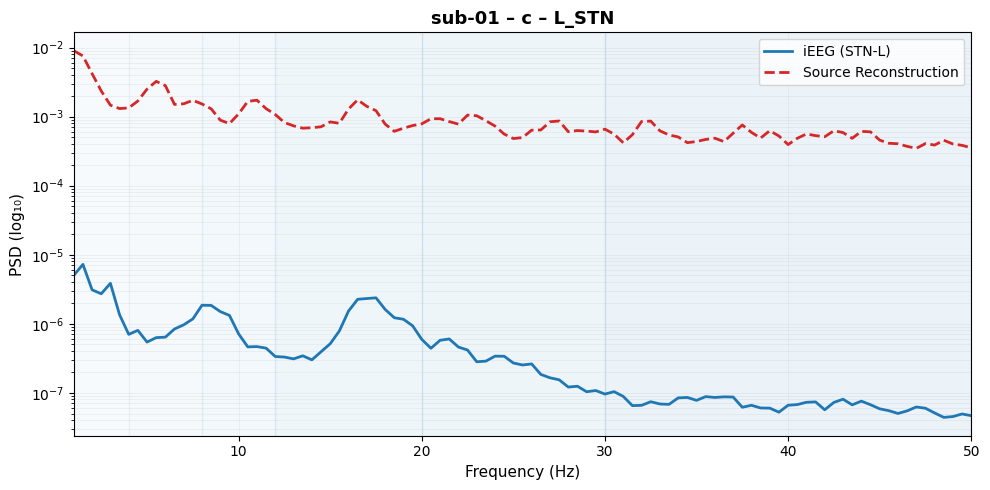


📊 Processing R_STN
  → iEEG: STN-R @ 250.0 Hz
Requested: [12.53, -13.97, -6.57]
Closest active source: [15.0, -15.0, -5.0] (dist: 3.1 mm)


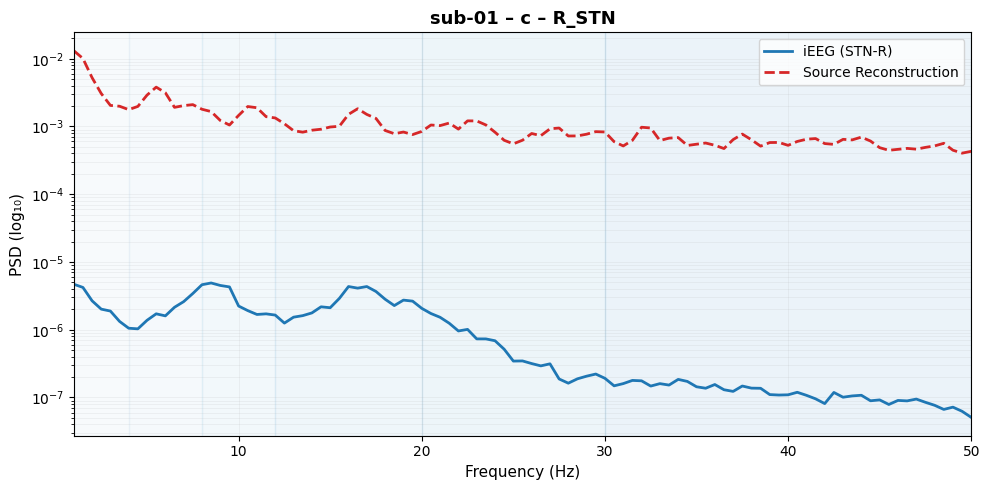


✅ Validation complete


In [6]:
# Validate LCMV vs iEEG for Subject 01 at 4 canonical ROIs:
"""
- L_M1: [-40.0, -12.5, 66.0]
- R_M1: [ 40.0, -12.5, 66.0]
- L_STN: [-11.89, -14.51, -6.40]
- R_STN: [ 12.53, -13.97, -6.57]

Uses your lcmv_xtra.viz.compute_psd and imat-style PSD layout.
"""

import numpy as np
import matplotlib.pyplot as plt
import mne
from pathlib import Path
from scipy.integrate import trapezoid
import scipy.signal as signal

# =============================================================================
# CONFIGURATION
# =============================================================================

SUBJECT = "sub-01"
RUN = "c"  # one of: c, o, l, r

# Paths
IEEG_FILE = Path(f"/mnt/movement/users/jaizor/xtra/derivatives/dbs/trials/rest_off/{SUBJECT}/rest_off_{SUBJECT}_{RUN}_ieeg.npz")
LCMV_FILE = Path(f"/mnt/movement/users/jaizor/xtra/derivatives/lcmv/{SUBJECT}_rest_off_{RUN}/source_estimate_LCMV.h5")
FS_DIR = "/mnt/movement/users/jaizor/xtra/derivatives/_fs"

# Canonical ROIs + iEEG channel mapping
ROI_CONFIG = {
    "L_M1":  { "mni": [-40.0, -12.5, 66.0], "ieeg_ch": ["ECOG-8-9-L", "ECOG-10-11-L"] },
    "R_M1":  { "mni": [ 40.0, -12.5, 66.0], "ieeg_ch": ["ECOG-8-9-R", "ECOG-10-11-R"] },
    "L_STN": { "mni": [-11.89, -14.51, -6.40], "ieeg_ch": ["STN-L"] },
    "R_STN": { "mni": [ 12.53, -13.97, -6.57], "ieeg_ch": ["STN-R"] }
}

# =============================================================================
# PSD CONFIGURATION (copied from lcmv_xtra/viz.py)
# =============================================================================

SFREQ_DEFAULT = 500.0
PSD_WINDOW_SEC = 2.0

FREQ_BANDS = {
    'Delta': (1, 4),
    'Theta': (4, 8),
    'Alpha': (8, 12),
    'Low_Beta': (12, 20),
    'High_Beta': (20, 30),
    'Low_Gamma': (30, 50),
    'High_Gamma': (50, 100)
}

def _compute_band_powers(freqs: np.ndarray, psd: np.ndarray) -> dict:
    band_powers = {}
    df = freqs[1] - freqs[0]
    for band, (fmin, fmax) in FREQ_BANDS.items():
        mask = (freqs >= fmin) & (freqs <= fmax)
        if np.any(mask):
            band_powers[band] = trapezoid(psd[mask], dx=df)
        else:
            band_powers[band] = 0.0
    return band_powers

def compute_psd(time_series: np.ndarray, sfreq: float = SFREQ_DEFAULT, method: str = 'welch',
                fmin: float = 1.0, fmax: float = 100.0, window_sec: float = PSD_WINDOW_SEC):
    ts = np.real(time_series).astype(np.float64)
    window_size = int(window_sec * sfreq)
    if len(ts) < window_size:
        raise ValueError("Time series too short")

    nyq = sfreq * 0.5
    b, a = signal.butter(4, 0.5 / nyq, btype='high')
    filtered = signal.filtfilt(b, a, ts)

    if method == 'welch':
        freqs, psd = signal.welch(filtered, fs=sfreq, window='hann', nperseg=window_size,
                                   noverlap=window_size//2, detrend='constant')
        mask = (freqs >= fmin) & (freqs <= fmax)
        freqs, psd = freqs[mask], psd[mask]
    else:
        raise ValueError("Only 'welch' supported in this script")

    band_powers = _compute_band_powers(freqs, psd)
    return freqs.astype(np.float32), psd.astype(np.float32), band_powers

# =============================================================================
# MAIN FUNCTIONS
# =============================================================================

def load_ieeg(ieeg_path):
    npz = np.load(ieeg_path, allow_pickle=True)
    meta = npz['trial_metadata'].item()
    channels = {k: npz[k] for k in npz.files if k != 'trial_metadata'}
    return channels, meta

def extract_lcmv_time_series(stc_path, mni_coord, base_dir):
    stc = mne.read_source_estimate(str(stc_path))
    src = mne.read_source_spaces(Path(base_dir) / "fsaverage-vol-5mm-src.fif")
    
    active_vertices = stc.vertices[0]
    active_coords_mm = src[0]['rr'][active_vertices] * 1000  # m → mm
    
    target = np.array(mni_coord)
    distances = np.linalg.norm(active_coords_mm - target, axis=1)
    best_idx = np.argmin(distances)
    
    # ✅ FIX: cast to float to avoid formatting error
    print(f"Requested: {mni_coord}")
    print(f"Closest active source: [{float(active_coords_mm[best_idx][0]):.1f}, "
          f"{float(active_coords_mm[best_idx][1]):.1f}, {float(active_coords_mm[best_idx][2]):.1f}] "
          f"(dist: {float(distances[best_idx]):.1f} mm)")
    
    return stc.data[best_idx, :], stc.times

def plot_comparison(roi_name, ieeg_signal, ieeg_sfreq, lcmv_signal, lcmv_sfreq, ch_used):
    # Compute PSDs
    freqs_ieeg, psd_ieeg, _ = compute_psd(ieeg_signal, sfreq=ieeg_sfreq, fmax=50.0)
    freqs_lcmv, psd_lcmv, _ = compute_psd(lcmv_signal, sfreq=lcmv_sfreq, fmax=50.0)
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(freqs_ieeg, psd_ieeg, color='#1f77b4', linewidth=2.0, label=f'iEEG ({ch_used})')
    ax.plot(freqs_lcmv, psd_lcmv, color='#d62728', linewidth=2.0, linestyle='--', label='Source Reconstruction')
    
    # Band shading
    cmap = plt.colormaps.get_cmap("Blues")
    n_bands = len(FREQ_BANDS)
    for i, (band, (fmin, fmax)) in enumerate(FREQ_BANDS.items()):
        if fmax < freqs_ieeg[0] or fmin > freqs_ieeg[-1]:
            continue
        color_intensity = 0.3 + (i / max(n_bands - 1, 1)) * 0.4
        band_color = cmap(color_intensity)
        band_low = max(fmin, freqs_ieeg[0])
        band_high = min(fmax, freqs_ieeg[-1])
        ax.axvspan(band_low, band_high, color=band_color, alpha=0.10, zorder=0)
    
    ax.set_xlabel("Frequency (Hz)", fontsize=11)
    ax.set_ylabel("PSD (log₁₀)", fontsize=11)
    ax.set_yscale('log')
    ax.set_xlim(1, 50)
    ax.grid(True, which='both', alpha=0.2, linestyle='-', linewidth=0.5)
    ax.legend()
    ax.set_title(f"{SUBJECT} – {RUN} – {roi_name}", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

# =============================================================================
# RUN VALIDATION
# =============================================================================

if __name__ == '__main__':
    if not IEEG_FILE.exists():
        raise FileNotFoundError(f"iEEG file not found: {IEEG_FILE}")
    if not LCMV_FILE.exists():
        raise FileNotFoundError(f"LCMV file not found: {LCMV_FILE}")
    
    print(f"🔍 Loading iEEG: {IEEG_FILE.name}")
    ieeg_ch, ieeg_meta = load_ieeg(IEEG_FILE)
    
    print(f"Loading LCMV: {LCMV_FILE.name}")
    
    for roi_name, config in ROI_CONFIG.items():
        print(f"\n📊 Processing {roi_name}")
        
        # Get iEEG channel
        ch_used = None
        ieeg_signal = None
        for ch in config["ieeg_ch"]:
            if ch in ieeg_ch:
                ieeg_signal = ieeg_ch[ch]
                ch_used = ch
                break
        if ieeg_signal is None:
            print(f"  ⚠️ No iEEG channel found for {roi_name}")
            continue
        
        ieeg_sfreq = ieeg_meta['sfreq']
        print(f"  → iEEG: {ch_used} @ {ieeg_sfreq} Hz")
        
        # Get LCMV time series
        try:
            lcmv_signal, times = extract_lcmv_time_series(LCMV_FILE, config["mni"], FS_DIR)
            lcmv_sfreq = 1.0 / (times[1] - times[0])
        except Exception as e:
            print(f"  ❌ LCMV extraction failed: {e}")
            continue
        
        # Plot comparison
        plot_comparison(roi_name, ieeg_signal, ieeg_sfreq, lcmv_signal, lcmv_sfreq, ch_used)
    
    print("\n✅ Validation complete")